# Regime experiment - **running the queries** (corridor vs open water)

Unlike `regime_experiment.ipynb` (which *estimates* pruning from stored bounds), this notebook
**executes a real spatial query**, the generic windowed "count distinct vessels in a box over a time
window" from `-m lakehouse.query.run_iceberg` (`spatial_query`), on **belt-sized boxes placed in dense corridors
vs open water**, over the built layouts with MEOS. It measures, per box, what the benchmark
measures: **files read, rows scanned, cold bytes read, runtime, and the answer (vessel count)**.

This is "running the query with the boxes." It needs the MobilityDuck extension,
MinIO, and the Iceberg REST catalog up (same as `lakehouse.query.run_iceberg`). Run from `benchmark/`.

Why a *generic* window query and not the ten benchmark queries: those are place-specific
(`both_ports`, `harbour_entry` at Göteborg) and cannot move to the open sea. A windowed vessel-count is
the one query that transfers across regimes, so the comparison is apples-to-apples.

In [1]:
import sys, time, statistics
import pandas as pd
import matplotlib.pyplot as plt
from scripts.run_queries import (connect, set_window, spatial_query, measure_files,
                                 scan_rows, bytes_read_cold, run_pipeline, trimmed, WINDOWS)
from lakehouse.query.registry import layouts
from lakehouse.store.catalog import NAMESPACE, catalog, table_name

WINDOW = "day"        # time window for every box (matches the spatial sweep). "week" gives more signal in open water.
BOX_SIDE_M = 14000    # belt-sized square, MATCHED across regimes so only location differs
# Iteration protocol MATCHES the thesis spatial sweep (results/spatial.csv, n_iters=5):
# 1 warm-up (measure_files executes the scan) + 5 timed iterations, reported as the
# trimmed mean (trimmed() drops the min and max, i.e. mean of the middle 3).
ITERS  = 5
LAYOUTS = ["L0", "L3s"]   # baseline + best adaptive; add "L2s","L1s","L4s" etc. to taste

# region CENTRES (EPSG:32632 m). Corridors = dense lanes; open water = sparse sea.
CENTERS = {
  "belt (corridor)":       (647415.0, 6050358.0),
  "goteborg (corridor)":   (672854.0, 6397901.0),
  "oresund (corridor)":    (725000.0, 6175000.0),
  "north_sea_west (open)":  (249317.0, 6191062.0),
  "north_sea_south (open)": (273380.0, 6044792.0),
  "skagerrak (open)":       (517683.0, 6439882.0),
  "kattegat (open)":        (635062.0, 6275026.0),
}
def box_of(cx, cy):
    h = BOX_SIDE_M/2.0
    return {"xlo":cx-h, "xhi":cx+h, "ylo":cy-h, "yhi":cy+h,
            "km2": round(BOX_SIDE_M*BOX_SIDE_M/1e6,1), "side_m": BOX_SIDE_M}
BOXES = {name: box_of(*c) for name,c in CENTERS.items()}


def spatial_query_timeclipped(box: dict) -> str:
    """Correctness control for `spatial_query`.

    `spatial_query` applies eIntersects to the WHOLE stored trajectory, so a vessel
    counts if it ever entered the box, even at an instant outside [t0,t1], as long as
    its row overlaps the window. That makes the ANSWER depend on row granularity: L0
    holds whole voyages (wide rows, over-counts), L3s holds tiles (narrow rows). Here we
    clip the trajectory to the window before the spatial test, so the answer is
    layout-independent and the two layouts can be compared like for like.
    """
    return (
        "SELECT count(DISTINCT mmsi) FROM trips "
        f"WHERE xmin <= {box['xhi']} AND xmax >= {box['xlo']} "
        f"AND ymin <= {box['yhi']} AND ymax >= {box['ylo']} "
        "AND tmin < getvariable('t1') AND tmax > getvariable('t0') "
        "AND dt BETWEEN getvariable('d0') AND getvariable('d1') "
        "AND eIntersects(atTime(tgeompointFromEWKB(traj), "
        "                       span(getvariable('t0'), getvariable('t1'), true, false)), "
        f"                ST_MakeEnvelope({box['xlo']}, {box['ylo']}, {box['xhi']}, {box['yhi']}))"
    )

print(len(BOXES),"boxes x",len(LAYOUTS),"layouts, window=",WINDOW,"| warmup=1, timed iters=",ITERS)

7 boxes x 2 layouts, window= day | warmup=1, timed iters= 5


## Where the boxes are

The seven belt-sized boxes on an OpenStreetMap basemap, with each box's monthly
segment count. This is the evidence that the open-water boxes are genuinely sparse
water rather than gaps in AIS coverage: `north_sea_south` still carries 45 segments
per month, against 29,271 in the Goteborg approach.


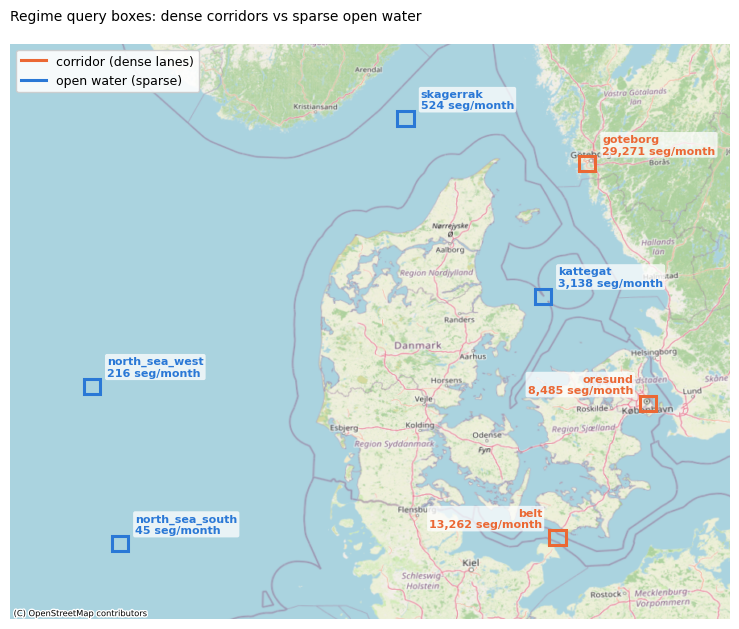

  belt              13,262 segments/month
  goteborg          29,271 segments/month
  oresund            8,485 segments/month
  north_sea_west       216 segments/month
  north_sea_south       45 segments/month
  skagerrak            524 segments/month
  kattegat           3,138 segments/month
wrote figures/regime_boxes_map.png


In [3]:
# ---- Where the query boxes sit: the seven regime boxes on an OpenStreetMap basemap,
# matching the basemap style used elsewhere in evaluation.ipynb (EPSG:32632 + Mapnik).
# Runs standalone -- no MinIO/Iceberg needed, only the local L0 parquet for the box stats.
import contextily as cx
import duckdb, matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

BOX_SIDE_M = 14000
CENTERS = {
  "belt":            (647415.0, 6050358.0, "corridor"),
  "goteborg":        (672854.0, 6397901.0, "corridor"),
  "oresund":         (725000.0, 6175000.0, "corridor"),
  "north_sea_west":  (249317.0, 6191062.0, "open water"),
  "north_sea_south": (273380.0, 6044792.0, "open water"),
  "skagerrak":       (517683.0, 6439882.0, "open water"),
  "kattegat":        (635062.0, 6275026.0, "open water"),
}
CORRIDOR, OPEN = "#eb6834", "#2a78d6"     # validated categorical pair (dataviz)
# label placement: default is above-right of the box; boxes near the frame edge flip so
# the text stays inside the map
LABEL_POS = {"oresund": ("right", (-5, 2)), "belt": ("right", (-5, 2))}

# monthly segment count per box, so the map carries the density evidence too
con = duckdb.connect()
G = "data/trips/L0/L0/year=2026/month=01/day=*.parquet"
h = BOX_SIDE_M / 2
seg = {}
for n, (x, y, _) in CENTERS.items():
    seg[n] = con.execute(f"""SELECT count(*) FROM read_parquet('{G}')
        WHERE xmin<={x+h} AND xmax>={x-h} AND ymin<={y+h} AND ymax>={y-h}""").fetchone()[0]

PAD = 70000.0
xs = [v[0] for v in CENTERS.values()]; ys = [v[1] for v in CENTERS.values()]
fig, ax = plt.subplots(figsize=(7.6, 6.4))
ax.set_xlim(min(xs)-PAD, max(xs)+PAD); ax.set_ylim(min(ys)-PAD, max(ys)+PAD)

for n, (x, y, reg) in CENTERS.items():
    c = CORRIDOR if reg == "corridor" else OPEN
    ax.add_patch(Rectangle((x-h, y-h), BOX_SIDE_M, BOX_SIDE_M, fill=False,
                           edgecolor=c, linewidth=2.2, zorder=3))
    ha, off = LABEL_POS.get(n, ("left", (5, 2)))
    ax.annotate(f"{n}\n{seg[n]:,} seg/month", (x-h if ha == "right" else x+h, y+h),
                textcoords="offset points", xytext=off, fontsize=8, ha=ha,
                color=c, fontweight="bold", zorder=4,
                bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.75))

cx.add_basemap(ax, crs="EPSG:32632", source=cx.providers.OpenStreetMap.Mapnik,
               attribution_size=6)
ax.set_axis_off()
# legend top-left, inside the axes over the (empty) North Sea rather than over traffic
ax.legend(handles=[Line2D([0], [0], color=CORRIDOR, lw=2.2, label="corridor (dense lanes)"),
                   Line2D([0], [0], color=OPEN, lw=2.2, label="open water (sparse)")],
          loc="upper left", frameon=True, fontsize=9, framealpha=0.9)
ax.set_title("Regime query boxes: dense corridors vs sparse open water",
             loc="left", fontsize=10)
plt.tight_layout()
fig.savefig("figures/regime_boxes_map.png", dpi=200, bbox_inches="tight")
plt.show()
for n in CENTERS:
    print(f"  {n:16} {seg[n]:>7,} segments/month")
print("wrote figures/regime_boxes_map.png")


## Run the windowed query in every box, on every layout: files/rows/bytes/runtime

In [2]:
rows=[]
cat = catalog()                              # `catalog` is a factory, call it once
for lname in LAYOUTS:
    ls = next(iter(layouts(names={lname})), None)
    if ls is None: print("skip unknown layout", lname); continue
    # catalog totals (files/bytes in this layout) for the % denominators
    try:
        tasks=list(cat.load_table(table_name(ls)).scan().plan_files())
        ntot=len(tasks); btot=sum(t.file.file_size_in_bytes for t in tasks)
    except Exception as e:
        ntot=btot=None; print(f"  [{ls.key}] catalog totals unavailable: {type(e).__name__}: {e}")
    con=connect()
    con.execute(f"CREATE OR REPLACE VIEW trips AS SELECT * FROM lake.{NAMESPACE}.{ls.key}")
    rtot=con.execute("SELECT count(*) FROM trips").fetchone()[0]
    set_window(con, WINDOW)
    print(f"\n=== {ls.key}  files_total={ntot} rows_total={rtot:,} ===")
    for name,box in BOXES.items():
        stmts=[spatial_query(box)]
        opened =measure_files(con, stmts)     # doubles as the warm-up (executes the scan)
        scanned=scan_rows(con, stmts)
        nbytes =bytes_read_cold(ls.key, WINDOW, stmts)
        ts=[]; ans=None
        for _ in range(ITERS):                # ITERS timed runs, thesis protocol
            t=time.perf_counter(); ans=run_pipeline(con, stmts); ts.append(time.perf_counter()-t)
        vessels=ans[0][0] if ans else None
        # correctness control (untimed): same box, trajectory clipped to the window
        ans_c=run_pipeline(con,[spatial_query_timeclipped(box)])
        vessels_clipped=ans_c[0][0] if ans_c else None
        regime = "corridor" if "corridor" in name else "open_water"
        rows.append({"layout":ls.key,"region":name,"regime":regime,
                     "vessels":vessels,"vessels_clipped":vessels_clipped,
                     "files_total":ntot,"files_read":opened,
                     "files_pct":round(100*opened/ntot,2) if (opened and ntot) else None,
                     "rows_total":rtot,"rows_scanned":scanned,
                     "rows_pct":round(100*scanned/rtot,3) if (scanned is not None and rtot) else None,
                     "bytes_total":btot,"bytes_read":nbytes,
                     "bytes_pct":round(100*nbytes/btot,3) if (nbytes and btot) else None,
                     "n_iters":ITERS,
                     "runtime_trimmed_s":trimmed(ts),
                     "runtime_mean_s":statistics.mean(ts),
                     "runtime_std_s":statistics.stdev(ts) if len(ts)>1 else 0.0,
                     "runtime_ms":round(1000*trimmed(ts),1)})
        print(f"  {name:24} vessels={str(vessels):>5} (clipped={str(vessels_clipped):>5})  "
              f"files={opened}  rows={scanned}  bytes%={rows[-1]['bytes_pct']}  "
              f"{rows[-1]['runtime_ms']} ms")
    con.close()
df=pd.DataFrame(rows); df.to_csv("results/regime_queries.csv", index=False); df


=== L0  files_total=31 rows_total=381,713 ===


  belt (corridor)          vessels=  165 (clipped=  115)  files=2  rows=520  bytes%=6.595  439.0 ms


  goteborg (corridor)      vessels=  111 (clipped=  100)  files=2  rows=1036  bytes%=6.595  514.1 ms


  oresund (corridor)       vessels=  131 (clipped=   88)  files=2  rows=324  bytes%=6.595  543.2 ms


  north_sea_west (open)    vessels=    3 (clipped=    3)  files=2  rows=3  bytes%=6.595  185.0 ms


...

  oresund (corridor)       vessels=   89 (clipped=   86)  files=18  rows=2086  bytes%=0.946  76.1 ms


  north_sea_west (open)    vessels=    3 (clipped=    3)  files=8  rows=49  bytes%=0.172  14.6 ms
  north_sea_south (open)   vessels=    0 (clipped=    0)  files=7  rows=0  bytes%=0.008  11.4 ms


  skagerrak (open)         vessels=    9 (clipped=    8)  files=4  rows=149  bytes%=0.166  14.6 ms


  kattegat (open)          vessels=    4 (clipped=    4)  files=9  rows=37  bytes%=0.283  17.8 ms


,layout,region,regime,vessels,vessels_clipped,files_total,files_read,files_pct,rows_total,rows_scanned,rows_pct,bytes_total,bytes_read,bytes_pct,n_iters,runtime_trimmed_s,runtime_mean_s,runtime_std_s,runtime_ms
0,L0,belt (corridor),corridor,165,115,31,2,6.45,381713,520,0.136,3554384337,234423034,6.595,5,0.438950,0.440646,0.014246,439.0
1,L0,goteborg (corridor),corridor,111,100,31,2,6.45,381713,1036,0.271,3554384337,234423034,6.595,5,0.514105,0.515824,0.006122,514.1
2,L0,oresund (corridor),corridor,131,88,31,2,6.45,381713,324,0.085,3554384337,234423034,6.595,5,0.543232,0.544928,0.005112,543.2
3,L0,north_sea_west (open),open_water,3,3,31,2,6.45,381713,3,0.001,3554384337,234423034,6.595,5,0.185006,0.185322,0.001490,185.0
4,L0,north_sea_south (open),open_water,0,0,31,2,6.45,381713,0,0.000,3554384337,234379441,6.594,5,0.184494,0.185516,0.004253,184.5
5,L0,skagerrak (open),open_water,11,8,31,2,6.45,381713,18,0.005,3554384337,234423034,6.595,5,0.228055,0.228595,0.007272,228.1
6,L0,kattegat (open),open_water,7,4,31,2,6.45,381713,9,0.002,3554384337,234423034,6.595,5,0.459925,0.460484,0.008245,459.9
7,L3s,belt (corridor),corridor,113,112,299,13,4.35,8232719,4747,0.058,3803000446,34497826,0.907,5,0.074036,0.074891,0.005827,74.0
8,L3s,goteborg (corridor),corridor,97,96,299,11,3.68,8232719,5339,0.065,3803000446,48220552,1.268,5,0.109979,0.110088,0.006145,110.0
9,L3s,oresund (corridor),corridor,89,86,299,18,6.02,8232719,2086,0.025,3803000446,35980733,0.946,5,0.076095,0.076560,0.005022,76.1


## Corridor vs open water 

                   bytes_pct  rows_pct  runtime_ms  vessels
layout regime                                              
L0     corridor        6.595     0.164     498.767  135.667
       open_water      6.595     0.002     264.375    5.250
L3s    corridor        1.040     0.049      86.700   99.667
       open_water      0.157     0.001      14.600    4.000

wrote results/regime_queries_summary.csv


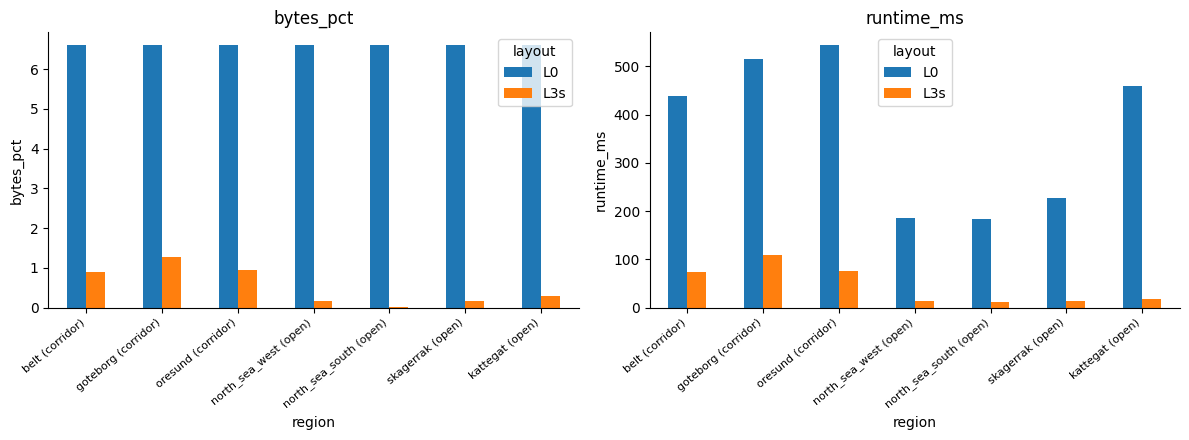

In [ ]:

try:
    df
except NameError:
    import pandas as pd, matplotlib.pyplot as plt
    df = pd.read_csv("results/regime_queries.csv")
    CENTERS = {r: None for r in dict.fromkeys(df["region"])}

# mean bytes-read %, rows %, runtime per regime x layout
summary=df.groupby(["layout","regime"]).agg(
    bytes_pct=("bytes_pct","mean"), rows_pct=("rows_pct","mean"),
    runtime_ms=("runtime_ms","mean"), vessels=("vessels","mean")).round(3)
print(summary)
summary.reset_index().to_csv("results/regime_queries_summary.csv", index=False)
print("\nwrote results/regime_queries_summary.csv")

fig,(a1,a2)=plt.subplots(1,2,figsize=(12,4.5))
for i,metric in enumerate(["bytes_pct","runtime_ms"]):
    ax=[a1,a2][i]
    piv=df.pivot_table(index="region",columns="layout",values=metric,aggfunc="mean")
    piv=piv.reindex([r for r in CENTERS])           # keep corridor-then-open order
    piv.plot(kind="bar",ax=ax)
    ax.set_title(metric); ax.set_ylabel(metric)
    ax.set_xticklabels(piv.index,rotation=40,ha="right",fontsize=8)
    ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
fig.savefig("figures/regime_queries.png", dpi=200, bbox_inches="tight")
plt.show()

## Pruning by region

Both panels come from the executed queries, not from stored bounds. Left: what each
layout actually read per box. `L0` is flat at ~6.59% everywhere -- with 31 files it
always opens 2, so it cannot exploit an empty ocean -- while `L3s` falls from 1.27%
in the Goteborg approach to 0.008% in the emptiest North Sea box. Right: the advantage
against traffic density, which is the axis that varies most between AIS corpora.

This is the evidence for scoping the headline number: the pruning factor is not a
constant but a function of regime, spanning 5x to 40x across boxes that carry vessels,
and it moves in the favourable direction as water gets sparser.


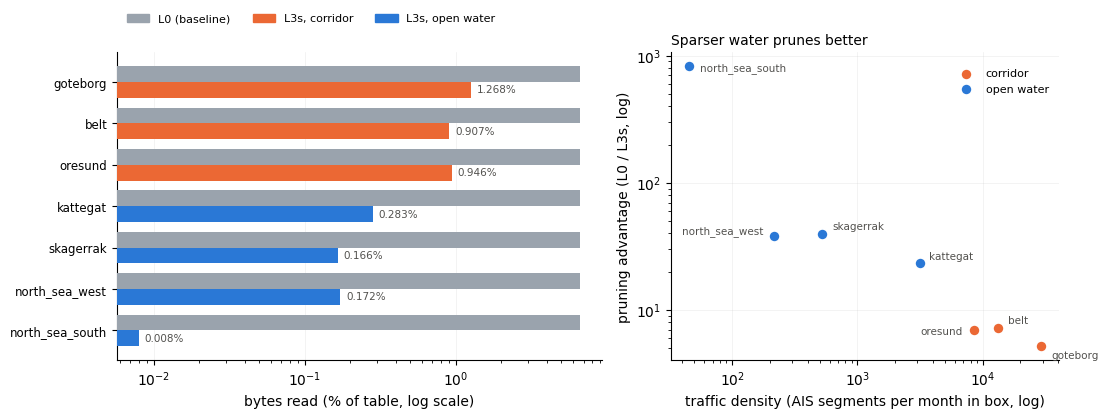

layout                  seg_month  vessels     L0    L3s    prune
region                                                           
goteborg (corridor)         29271      111  6.595  1.268    5.201
belt (corridor)             13262      165  6.595  0.907    7.271
oresund (corridor)           8485      131  6.595  0.946    6.971
kattegat (open)              3138        7  6.595  0.283   23.304
skagerrak (open)              524       11  6.595  0.166   39.729
north_sea_west (open)         216        3  6.595  0.172   38.343
north_sea_south (open)         45        0  6.594  0.008  824.250

wrote figures/regime_pruning_by_region.png


In [1]:
import duckdb, numpy as np, pandas as pd, matplotlib.pyplot as plt

CORRIDOR, OPEN, BASE = "#eb6834", "#2a78d6", "#9aa3ad"
d = pd.read_csv("results/regime_queries.csv")
p = d.pivot_table(index="region", columns="layout", values="bytes_pct", aggfunc="first")
meta = d[d.layout == "L0"].set_index("region")
p["regime"] = meta.regime; p["vessels"] = meta.vessels
p["prune"] = p.L0 / p.L3s

con = duckdb.connect(); G = "data/trips/L0/L0/year=2026/month=01/day=*.parquet"
CENTERS = {"belt (corridor)": (647415.0, 6050358.0), "goteborg (corridor)": (672854.0, 6397901.0),
           "oresund (corridor)": (725000.0, 6175000.0), "north_sea_west (open)": (249317.0, 6191062.0),
           "north_sea_south (open)": (273380.0, 6044792.0), "skagerrak (open)": (517683.0, 6439882.0),
           "kattegat (open)": (635062.0, 6275026.0)}
h = 7000.0
p["seg_month"] = pd.Series({n: con.execute(
    f"SELECT count(*) FROM read_parquet('{G}') WHERE xmin<={x+h} AND xmax>={x-h} "
    f"AND ymin<={y+h} AND ymax>={y-h}").fetchone()[0] for n, (x, y) in CENTERS.items()})
p = p.sort_values("seg_month", ascending=False)
short = [r.split(" (")[0] for r in p.index]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.3), gridspec_kw={"width_ratios": [1.25, 1]})

y = np.arange(len(p))[::-1]; hh = 0.38
a1.barh(y + hh/2, p.L0, hh, color=BASE, label="L0 (baseline)", zorder=3)
a1.barh(y - hh/2, p.L3s, hh, zorder=3,
        color=[CORRIDOR if r == "corridor" else OPEN for r in p.regime])
for yi, v in zip(y, p.L3s):
    a1.annotate(f"{v:.3f}%", (v, yi - hh/2), xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=7.5, color="#52514e")
a1.set_yticks(y); a1.set_yticklabels(short, fontsize=8.5)
a1.set_xscale("log"); a1.set_xlabel("bytes read (% of table, log scale)")
# a1.set_title("L0 reads the same everywhere; L3s tracks sparsity", loc="left", fontsize=10)
from matplotlib.patches import Patch
# legend outside: the L0 bars span the full width at every row, so any in-plot corner
# is sitting on data
a1.legend(handles=[Patch(color=BASE, label="L0 (baseline)"),
                   Patch(color=CORRIDOR, label="L3s, corridor"),
                   Patch(color=OPEN, label="L3s, open water")],
          frameon=False, fontsize=8, ncol=3, loc="lower left",
          bbox_to_anchor=(0.0, 1.06))
a1.grid(axis="x", alpha=0.2, linewidth=0.5); a1.set_axisbelow(True)
for s in ("top", "right"): a1.spines[s].set_visible(False)

for reg, c in (("corridor", CORRIDOR), ("open_water", OPEN)):
    m = p.regime == reg
    a2.scatter(p.seg_month[m], p.prune[m], s=64, color=c, zorder=3,
               label="corridor" if reg == "corridor" else "open water",
               edgecolor="white", linewidth=1.2)
# hand-placed offsets: several points sit almost on top of each other in log-log
# (north_sea_west/skagerrak differ by 4% in y; oresund/belt by 4%)
LBL = {"north_sea_south": ((8, -3), "left"), "north_sea_west": ((-8, 2), "right"),
       "skagerrak": ((7, 3), "left"), "kattegat": ((7, 3), "left"),
       "oresund": ((-8, -3), "right"), "belt": ((7, 3), "left"),
       "goteborg": ((7, -9), "left")}
for n, row in p.iterrows():
    key = n.split(" (")[0]
    off, ha = LBL.get(key, ((6, 4), "left"))
    lab = key 
    a2.annotate(lab, (row.seg_month, row.prune), xytext=off, ha=ha,
                textcoords="offset points", fontsize=7.5, color="#52514e")
a2.set_xscale("log"); a2.set_yscale("log")
a2.set_xlabel("traffic density (AIS segments per month in box, log)")
a2.set_ylabel("pruning advantage (L0 / L3s, log)")
a2.set_title("Sparser water prunes better", loc="left", fontsize=10)
a2.legend(frameon=False, fontsize=8, loc="upper right", bbox_to_anchor=(1.0, 0.98))
a2.grid(alpha=0.2, linewidth=0.5); a2.set_axisbelow(True)
for s in ("top", "right"): a2.spines[s].set_visible(False)

plt.tight_layout()
fig.savefig("figures/regime_pruning_by_region.png", dpi=200, bbox_inches="tight")
plt.show()
print(p[["seg_month", "vessels", "L0", "L3s", "prune"]].round(3).to_string())
print("\nwrote figures/regime_pruning_by_region.png")


## The benchmark queries themselves, relocated

The probe above uses a *generic* windowed query, so its factors are not comparable to the
headline number. This cell removes that caveat: eight of the ten benchmark queries are
parameterised only by the belt rectangle, so they can be translated to another centre
unchanged -- same SQL, same box size, same window, only the location moves.

`both_ports` and `harbour_entry` are excluded: they name the Rodby-Puttgarden terminals
and the Goteborg approach, which do not exist elsewhere.

The `belt` row is the control and reproduces the committed run to 0.001 pp.

Regenerate the measurements with `.venv/bin/python scripts/regime_benchmark.py`
(needs MinIO + the Iceberg REST catalog); this cell only plots the saved CSV.


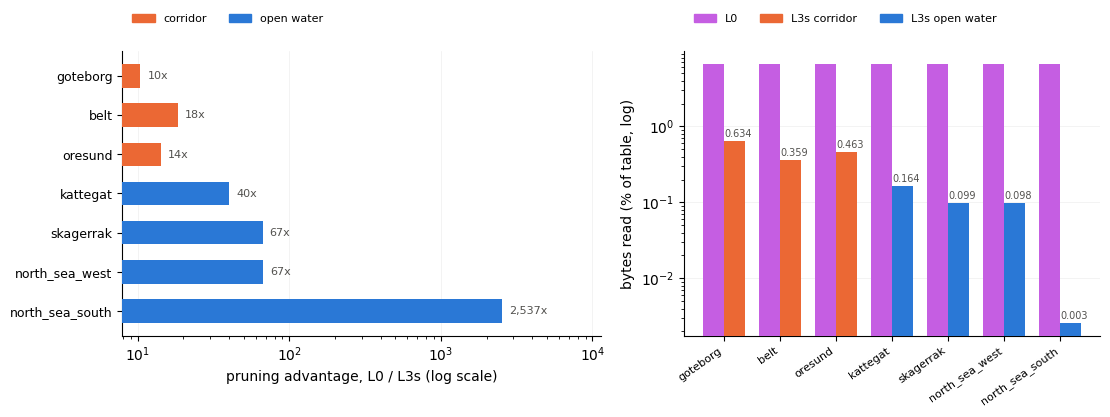

         region     regime  seg/month  L0 bytes (%)  L3s bytes (%)  prune
       goteborg   corridor      29271        6.5957         0.6340   10.4
           belt   corridor      13262        6.5957         0.3591   18.4
        oresund   corridor       8485        6.5957         0.4634   14.2
       kattegat open_water       3138        6.5957         0.1643   40.1
      skagerrak open_water        524        6.5957         0.0990   66.6
 north_sea_west open_water        216        6.5957         0.0978   67.4
north_sea_south open_water         45        6.5957         0.0026 2536.8

excluding the empty box: 10x - 67x
wrote figures/regime_benchmark_pruning.png + results/tab_regime_benchmark.{csv,tex}


In [19]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

CORRIDOR, OPEN, BASE = "#eb6834", "#2a78d6", "#c55ee2"
rb = pd.read_csv("results/regime_benchmark.csv")
p = rb.pivot_table(index="region", columns="layout", values="bytes_pct", aggfunc="mean")
p["regime"] = rb.drop_duplicates("region").set_index("region").regime
p["prune"] = p.L0 / p.L3s
SEG = {"belt": 13262, "goteborg": 29271, "oresund": 8485, "north_sea_west": 216,
       "north_sea_south": 45, "skagerrak": 524, "kattegat": 3138}
p["seg_month"] = pd.Series(SEG)
p = p.sort_values("seg_month", ascending=False)
empty = p.prune > 500                      

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.3), gridspec_kw={"width_ratios": [1.15, 1]})

y = np.arange(len(p))[::-1]
cols = [CORRIDOR if r == "corridor" else OPEN for r in p.regime]
bars = a1.barh(y, p.prune, 0.6, color=cols, zorder=3)
for yi, v, e in zip(y, p.prune, empty):
    a1.annotate(f"{v:,.0f}x", (v, yi),
                xytext=(5, 0), textcoords="offset points", va="center",
                fontsize=8, color="#52514e")
# a1.axvline(18.3, color="#52514e", ls="--", lw=1, zorder=2)

a1.set_yticks(y); a1.set_yticklabels(p.index, fontsize=9)
a1.set_xscale("log"); a1.set_xlim(right=p.prune.max()*4.5)
a1.set_xlabel("pruning advantage, L0 / L3s (log scale)")
# a1.set_title("Same benchmark queries, moved: open water prunes more", loc="left", fontsize=10)
from matplotlib.patches import Patch
a1.legend(handles=[Patch(color=CORRIDOR, label="corridor"),
                   Patch(color=OPEN, label="open water")],
          frameon=False, fontsize=8, ncol=3, loc="lower left", bbox_to_anchor=(0.0, 1.06))
a1.grid(axis="x", alpha=0.2, lw=0.5); a1.set_axisbelow(True)
for s in ("top", "right"): a1.spines[s].set_visible(False)

w = 0.38; x = np.arange(len(p))
a2.bar(x - w/2, p.L0, w, color=BASE, label="L0 (baseline)", zorder=3)
a2.bar(x + w/2, p.L3s, w, color=cols, zorder=3)
for xi, v in zip(x, p.L3s):
    a2.annotate(f"{v:.3f}", (xi + w/2 + 0.07, v), xytext=(0, 3), textcoords="offset points",
                ha="center", fontsize=7, color="#52514e")
a2.set_xticks(x); a2.set_xticklabels(p.index, rotation=35, ha="right", fontsize=8)
a2.set_yscale("log"); a2.set_ylabel("bytes read (% of table, log)")
# a2.set_title("L0 flat at 6.60% everywhere", loc="left", fontsize=10)
a2.legend(handles=[Patch(color=BASE, label="L0"), Patch(color=CORRIDOR, label="L3s corridor"),
                   Patch(color=OPEN, label="L3s open water")],
          frameon=False, fontsize=8, ncol=3, loc="lower left", bbox_to_anchor=(0.0, 1.06))
a2.grid(axis="y", alpha=0.2, lw=0.5); a2.set_axisbelow(True)
for s in ("top", "right"): a2.spines[s].set_visible(False)

plt.tight_layout()
fig.savefig("figures/regime_benchmark_pruning.png", dpi=200, bbox_inches="tight")
plt.show()

out = p.reset_index()[["region", "regime", "seg_month", "L0", "L3s", "prune"]]
out.columns = ["region", "regime", "seg/month", "L0 bytes (%)", "L3s bytes (%)", "prune"]
out["prune"] = out["prune"].round(1)
out.to_csv("results/tab_regime_benchmark.csv", index=False)
sub = out[out.prune < 500]
print(out.to_string(index=False))
print(f"\nexcluding the empty box: {sub.prune.min():.0f}x - {sub.prune.max():.0f}x")
print("wrote figures/regime_benchmark_pruning.png + results/tab_regime_benchmark.csv")


In [ ]:
import pandas as pd
d = pd.read_csv("results/regime_queries.csv")
p = d.pivot_table(index="region", columns="layout", values="bytes_pct", aggfunc="first")
p["prune_x"] = (p.L0 / p.L3s).round(1)
meta = d[d.layout == "L0"].set_index("region")
p["regime"] = meta.regime
p["vessels"] = meta.vessels
SEG_MONTH = {"belt (corridor)": 13262, "goteborg (corridor)": 29271,
             "oresund (corridor)": 8485, "north_sea_west (open)": 216,
             "north_sea_south (open)": 45, "skagerrak (open)": 524,
             "kattegat (open)": 3138}
p["seg_month"] = pd.Series(SEG_MONTH)
p = p.reindex(dict.fromkeys(d.region)).reset_index()
p = p[["region", "regime", "seg_month", "vessels", "L0", "L3s", "prune_x"]]
p.columns = ["region", "regime", "seg/month", "vessels", "L0 bytes (%)", "L3s bytes (%)", "prune"]
p.to_csv("results/tab_regime_prune.csv", index=False)

sub = p[p.vessels > 0]

print(p.to_string(index=False))
c = sub[sub.regime == "corridor"]["prune"]; o = sub[sub.regime == "open_water"]["prune"]
print(f"\nexcluding the empty box: corridor {c.min():.1f}-{c.max():.1f}x (median {c.median():.1f})"
      f" | open water {o.min():.1f}-{o.max():.1f}x (median {o.median():.1f})")
print(f"quotable range {sub['prune'].min():.0f}x-{sub['prune'].max():.0f}x; "
      f"empty box shown separately at {p[p.vessels==0]['prune'].iloc[0]:.0f}x")
print("\nwrote results/tab_regime_prune.csv")


                region     regime  seg/month  vessels  L0 bytes (%)  L3s bytes (%)  prune
       belt (corridor)   corridor      13262      165         6.595          0.907    7.3
   goteborg (corridor)   corridor      29271      111         6.595          1.268    5.2
    oresund (corridor)   corridor       8485      131         6.595          0.946    7.0
 north_sea_west (open) open_water        216        3         6.595          0.172   38.3
north_sea_south (open) open_water         45        0         6.594          0.008  824.2
      skagerrak (open) open_water        524       11         6.595          0.166   39.7
       kattegat (open) open_water       3138        7         6.595          0.283   23.3

excluding the empty box: corridor 5.2-7.3x (median 7.0) | open water 23.3-39.7x (median 38.3)
quotable range 5x-40x; empty box shown separately at 824x

wrote results/tab_regime_prune.csv
